# SNN vs Input Clarification Ensembling (Hou et al. 2024)

This notebook replicates the experimental methodology from *Decomposing Uncertainty
for Large Language Models through Input Clarification Ensembling* (Hou et al.,
arXiv:2311.08718v2, ICML 2024) and compares it head-to-head with the Subjective
Neural Network (SNN) framework.

### Core idea
Both methods decompose total predictive uncertainty into epistemic and aleatoric
components using the **same mathematical identity**:

$$\mathcal{H}(q(Y|X)) = \underbrace{\mathcal{I}(Y; Z | X)}_{\text{term }\textcircled{1}} + \underbrace{\mathbb{E}_{Z}[\mathcal{H}(q(Y|X,Z))]}_{\text{term }\textcircled{2}}$$

The interpretation of each term **depends on what is varied** (Z):

| Method | Z (varied) | MI (term 1) | Expected H (term 2) |
|--------|------------|-------------|---------------------|
| SNN / BNN / Deep Ensembles | Model parameters $\theta$ | **Epistemic** (model disagreement) | **Aleatoric** (avg per-model entropy) |
| Input Clarification Ensembling | Input clarifications $C$ | **Aleatoric** (input ambiguity) | **Epistemic** (avg per-clarification entropy) |

### Experiments (adapted from the paper)
1. **Mistake Detection** (Paper Table 1): Total uncertainty predicts misclassification
2. **Ambiguity Detection** (Paper Table 2): Aleatoric uncertainty detects ambiguous inputs
3. **Monotonicity Check** (Paper Figure 4a): Aleatoric drops after input clarification
4. **OOD Detection**: Epistemic uncertainty detects out-of-distribution inputs
5. **Rotation Sweep**: Full decomposition under covariate shift

### Methods compared
- **SNN** (Subjective Neural Network): Beta-Bernoulli trust draws
- **ICE** (Input Clarification Ensembling): Image augmentations as "clarifications"
- **Deep Ensembles**: Multiple independently trained models
- **MC Dropout**: Dropout masks as approximate posterior samples
- **EDL** (Evidential Deep Learning): Dirichlet-based uncertainty

In [35]:
# Uncomment if running on Colab:
# !git clone https://github.com/Ouatt-Isma/Subjective-Neural-Network-Framework.git
# %cd Subjective-Neural-Network-Framework
# !pip install -q -r requirements.txt

In [36]:
%matplotlib inline
import argparse, math, os, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from snn_eval import run_mnist, models, inference, metrics, cache
from snn_eval import augmented as aug

In [85]:
# ---- Hyperparameters ----
ARCH       = "resnet"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 15
D_HIDDEN   = 256
BETA_MAX   = 100
Np, Nm     = 50, 50      # SNN nested-sampling budget
T_MCD      = 100         # MC Dropout forward passes
N_ENSEMBLE = 5           # Deep Ensemble members
N_CLARIFY  = 10          # ICE augmented copies per image
SEED       = 0
N_TEST     = 2000        # test samples per experiment (speed vs precision)

print(f"device={DEVICE}  arch={ARCH}  epochs={EPOCHS}")

device=cuda  arch=resnet  epochs=15


## 1. Data

In [86]:
import torchvision as tv, torchvision.transforms as T

tf = T.ToTensor()
tr_ds  = tv.datasets.MNIST("./data", train=True,  download=True, transform=tf)
te_ds  = tv.datasets.MNIST("./data", train=False, download=True, transform=tf)
ood_ds = tv.datasets.FashionMNIST("./data", train=False, download=True, transform=tf)

def imgs(ds, n):
    X = torch.stack([ds[i][0] for i in range(min(n, len(ds)))])
    y = torch.tensor([ds[i][1] for i in range(min(n, len(ds)))])
    return X, y

Xtr_i, ytr     = imgs(tr_ds, 60000)
Xte_i, yte     = imgs(te_ds, N_TEST)
Xood_i, _      = imgs(ood_ds, N_TEST)
K = 10

Xtr  = run_mnist._prep_inputs(Xtr_i,  ARCH)
Xte  = run_mnist._prep_inputs(Xte_i,  ARCH)
Xood = run_mnist._prep_inputs(Xood_i, ARCH)

print(f"Train: {len(ytr)}  Test: {len(yte)}  OOD: {Xood_i.shape[0]}  K={K}")

Train: 60000  Test: 2000  OOD: 2000  K=10


## 2. Model Training

### 2.1 SNN / MC Dropout / EDL (cached from a2.ipynb)

In [87]:
base_args = run_mnist.build_argparser().parse_args([])
base_args.arch, base_args.device = ARCH, DEVICE
base_args.epochs, base_args.d_hidden = EPOCHS, D_HIDDEN
base_args.beta_max, base_args.seed = BETA_MAX, SEED
base_args.Np, base_args.Nm, base_args.T = Np, Nm, T_MCD

heads = run_mnist.build_or_train_models(
    base_args, K, Xtr, ytr, Xte, yte, exp_name="run_mnist"
)
snn_model = heads["snn"]
mcd_model = heads["mcd"]
edl_model = heads["edl"]

[models] loaded ['edl', 'mcd', 'snn'] ← results/models/run_mnist_b59cdbba6bd7/
[training skipped — models loaded from cache]


### 2.2 Deep Ensemble (5 independently trained models)

In [88]:
def build_det_model(arch, d_hidden, K):
    """Deterministic model (no dropout) for ensemble members."""
    if arch == "mlp":
        return models.LinearHead(784, d_hidden, K, p_drop=0.0)
    return models.MCDropoutCNN(arch, d_hidden, K, p_drop=0.0)


def train_or_load_ensemble(arch, d_hidden, K, Xtr, ytr, Xte, yte,
                           n_models=5, epochs=15, device="cpu"):
    ensemble = []
    exp = "deep_ensemble"
    for i in range(n_models):
        seed_i = i * 42 + 7
        tp = {"arch": arch, "d_hidden": d_hidden, "epochs": epochs,
              "seed": seed_i, "member": i}
        model = build_det_model(arch, d_hidden, K)
        loaded = cache.load_models(exp, tp, det=model)
        if "det" not in loaded:
            print(f"\n[Training ensemble member {i+1}/{n_models} (seed={seed_i})]")
            torch.manual_seed(seed_i)
            model = build_det_model(arch, d_hidden, K)
            models.train_head(model, Xtr, ytr, K, epochs=epochs,
                              device=device, verbose=True, Xte=Xte, yte=yte)
            cache.save_models(exp, tp, det=model)
        ensemble.append(model)
    return ensemble


ensemble = train_or_load_ensemble(
    ARCH, D_HIDDEN, K, Xtr, ytr, Xte, yte,
    n_models=N_ENSEMBLE, epochs=EPOCHS, device=DEVICE
)
print(f"\nEnsemble ready: {N_ENSEMBLE} members")

[models] loaded ['det'] ← results/models/deep_ensemble_a11c6a489bec/
[models] loaded ['det'] ← results/models/deep_ensemble_c432d2696858/
[models] loaded ['det'] ← results/models/deep_ensemble_b4bc0e408abb/
[models] loaded ['det'] ← results/models/deep_ensemble_ce5bd5ba9f3c/
[models] loaded ['det'] ← results/models/deep_ensemble_8ebf4fe41526/

Ensemble ready: 5 members


## 3. Uncertainty Decomposition Implementations

Every method produces three scalars per sample: **total**, **aleatoric**, **epistemic** uncertainty, plus a predicted probability vector. The BALD identity $H = \text{MI} + \text{eH}$ is used throughout; what differs is *what is ensembled* and thus *which term maps to which uncertainty type*.

In [89]:
# ================================================================
# 3.1  SNN  (vary trust parameters theta ~ Beta(alpha, beta))
# ================================================================
@torch.no_grad()
def snn_uncertainty(model, X_img, arch, Np, Nm, device):
    X = run_mnist._prep_inputs(X_img, arch)
    raw, pb = inference.snn_nested_samples(model, X, Np, Nm, device, desc="SNN")
    # Use bald_split on per-beta soft means (B, Np, K) directly,
    # avoiding augmented_opinion's argmax counting which compresses entropy.
    H_total, eH, MI, u = aug.bald_split(pb)
    return {
        "probs":     pb.mean(dim=1),
        "total":     H_total,
        "epistemic": MI,
        "aleatoric": eH,
        "u_star":    u,
    }


# ================================================================
# 3.2  MC Dropout  (vary dropout masks)
# ================================================================
@torch.no_grad()
def mcd_uncertainty(model, X_img, arch, T, device):
    X = run_mnist._prep_inputs(X_img, arch)
    pm, sm = inference.mc_dropout_probs(model, X, T=T, device=device, desc="MCD")
    op = aug.bald_opinion(sm)
    return {
        "probs":     op["probs"],
        "total":     op["H_total"],
        "epistemic": op["MI"],
        "aleatoric": op["eH"],
        "u_star":    op["u"],
    }


# ================================================================
# 3.3  EDL  (Dirichlet-based, no decomposition into epi/alea)
# ================================================================
@torch.no_grad()
def edl_uncertainty(model, X_img, arch, device):
    X = run_mnist._prep_inputs(X_img, arch)
    pe, ue = inference.edl_opinion(model, X, device)
    H = -(pe.clamp_min(1e-12) * pe.clamp_min(1e-12).log()).sum(-1)
    return {
        "probs":     pe,
        "total":     H,
        "epistemic": ue,       # vacuity (K/S) as epistemic proxy
        "aleatoric": H - ue,   # residual
        "u_star":    ue,
    }


# ================================================================
# 3.4  Deep Ensembles  (vary model weights across ensemble members)
#      MI = epistemic,  eH = aleatoric   (same as BNN / SNN)
# ================================================================
@torch.no_grad()
def de_uncertainty(ensemble, X_img, arch, device):
    X = run_mnist._prep_inputs(X_img, arch)
    all_probs = []
    for m in ensemble:
        m.eval().to(device)
        logits = m(X.to(device), sample=False)
        all_probs.append(F.softmax(logits, dim=1).cpu())
    samples = torch.stack(all_probs, dim=1)   # (B, N_models, K)
    op = aug.bald_opinion(samples)
    return {
        "probs":     op["probs"],
        "total":     op["H_total"],
        "epistemic": op["MI"],
        "aleatoric": op["eH"],
        "u_star":    op["u"],
    }


# ================================================================
# 3.5  Input Clarification Ensembling  (Hou et al. 2024, adapted)
#
#      The paper generates *text* clarifications of ambiguous questions.
#      For images, we use aggressive augmentations as "clarifications"
#      to simulate the diversity of text clarifications: large rotations,
#      translations, patch occlusion, noise, and contrast jitter.
#
#      KEY DIFFERENCE: here we vary the INPUT, not the model.
#        MI  = aleatoric  (different inputs -> different answers -> input ambiguity)
#        eH  = epistemic  (residual per-clarification uncertainty -> knowledge gap)
# ================================================================
def generate_clarifications(X_img, n_clarifications=20, seed=42):
    """Generate aggressively augmented 'clarified' versions of each image.

    Uses strong augmentations (large rotations, heavy noise, patch occlusion,
    contrast jitter) to ensure each clarification yields substantively
    different model predictions -- analogous to the diversity of text
    clarifications in the paper.
    """
    g = torch.Generator().manual_seed(seed)
    versions = [X_img]  # C^(0) = original
    B, C, H, W = X_img.shape
    for i in range(n_clarifications - 1):
        # Large rotation: +/- 45 degrees
        angle = (torch.rand(1, generator=g).item() - 0.5) * 90
        X_aug = run_mnist.rotate_batch(X_img, angle)

        # Translation: +/- 4 pixels (0.14 of 28px)
        tx = (torch.rand(1, generator=g).item() - 0.5) * 0.28
        ty = (torch.rand(1, generator=g).item() - 0.5) * 0.28
        theta = torch.tensor([[1., 0., tx], [0., 1., ty]]).unsqueeze(0).repeat(B, 1, 1)
        grid = F.affine_grid(theta, X_aug.shape, align_corners=False)
        X_aug = F.grid_sample(X_aug, grid, align_corners=False, padding_mode="zeros")

        # Patch occlusion: 50% chance, random 7-11px square
        if torch.rand(1, generator=g).item() < 0.5:
            ph = 7 + int(torch.rand(1, generator=g).item() * 5)
            pw = 7 + int(torch.rand(1, generator=g).item() * 5)
            py = int(torch.rand(1, generator=g).item() * max(1, H - ph))
            px = int(torch.rand(1, generator=g).item() * max(1, W - pw))
            X_aug = X_aug.clone()
            X_aug[:, :, py:py+ph, px:px+pw] = 0.0

        # Heavy noise: sigma 0.05 - 0.25
        noise_std = 0.05 + torch.rand(1, generator=g).item() * 0.20
        X_aug = X_aug + torch.randn_like(X_aug) * noise_std

        # Contrast jitter: scale pixel intensities by 0.6 - 1.4x
        contrast = 0.6 + torch.rand(1, generator=g).item() * 0.8
        X_aug = X_aug * contrast

        X_aug = X_aug.clamp(0, 1)
        versions.append(X_aug)
    return versions


@torch.no_grad()
def ice_uncertainty(model, X_img, arch, n_clarifications, device, seed=42):
    """Input Clarification Ensembling (Hou et al. 2024, adapted for images).

    Step 1: generate clarifications (augmentations)
    Step 2: ensemble predictions across clarifications  (Eq. 3 in the paper)

    Decomposition (note the SWAP vs BNN/SNN):
      MI  = I(Y;C|X) ~= aleatoric   (input ambiguity)
      eH  = E_C[H(Y|X+C)] ~= epistemic  (model knowledge gap)
    """
    clarifications = generate_clarifications(X_img, n_clarifications, seed)
    model.eval().to(device)
    all_probs = []
    for X_c in clarifications:
        X = run_mnist._prep_inputs(X_c, arch)
        logits = model(X.to(device), sample=False)
        all_probs.append(F.softmax(logits, dim=1).cpu())
    samples = torch.stack(all_probs, dim=1)   # (B, n_clarifications, K)

    H_total, eH, MI, u = aug.bald_split(samples)
    return {
        "probs":     samples.mean(dim=1),
        "total":     H_total,
        "aleatoric": MI,      # SWAPPED: MI = aleatoric (input ambiguity)
        "epistemic": eH,      # SWAPPED: eH = epistemic (knowledge gap)
        "u_star":    u,       # aleatoric share (vs epistemic share in SNN)
    }


print("All uncertainty methods defined.")

All uncertainty methods defined.


## 4. Compute Uncertainties on Clean Test Set

In [90]:
# The ICE method uses a single deterministic model -- we reuse the MCD model
# in deterministic mode (sample=False), which is equivalent to a standard
# trained network (no dropout at inference).
ice_model = mcd_model

print("Computing uncertainties on clean test set...")
u_snn = snn_uncertainty(snn_model, Xte_i, ARCH, Np, Nm, DEVICE)
u_mcd = mcd_uncertainty(mcd_model, Xte_i, ARCH, T_MCD, DEVICE)
u_edl = edl_uncertainty(edl_model, Xte_i, ARCH, DEVICE)
u_de  = de_uncertainty(ensemble, Xte_i, ARCH, DEVICE)
u_ice = ice_uncertainty(ice_model, Xte_i, ARCH, N_CLARIFY, DEVICE)

all_methods = {
    "SNN":              u_snn,
    "MC Dropout":       u_mcd,
    "EDL":              u_edl,
    "Deep Ensembles":   u_de,
    "ICE (Hou et al.)": u_ice,
}
print("Done.")

Computing uncertainties on clean test set...


Done.


## 5. Experiment 1: Mistake Detection (Paper Section 4.2, Table 1)

Use **total uncertainty** on each test sample to predict whether the model's
prediction is correct. The paper evaluates this on NQ and GSM8K; we use
MNIST. Metrics: **AUROC**, **best F1**, and mean entropy for correct (\checkmark) vs wrong (\xmark) answers.

In [91]:
def best_f1_score(scores, labels):
    """Best binary F1 over all thresholds (higher score = positive)."""
    s, lab = metrics._np(scores), metrics._np(labels).astype(int)
    order = np.argsort(-s)
    s, lab = s[order], lab[order]
    tp_cum = np.cumsum(lab)
    fp_cum = np.cumsum(1 - lab)
    P = lab.sum()
    if P == 0:
        return 0.0
    prec = tp_cum / (np.arange(len(lab)) + 1)
    rec  = tp_cum / P
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return float(f1.max())


def mistake_detection(u_dict, yte):
    preds = u_dict["probs"].argmax(1)
    correct = (preds == yte)
    total_u = metrics._np(u_dict["total"])
    correct_np = metrics._np(correct).astype(int)
    wrong_labels = 1 - correct_np

    auroc = metrics._roc_auc(total_u, wrong_labels)
    f1 = best_f1_score(total_u, wrong_labels)
    ent_correct = total_u[correct_np == 1].mean() if correct_np.sum() > 0 else 0
    ent_wrong   = total_u[correct_np == 0].mean() if (1-correct_np).sum() > 0 else 0
    acc = correct_np.mean()
    return {"AUROC": auroc, "F1": f1 * 100, "Entropy(V)": ent_correct,
            "Entropy(X)": ent_wrong, "Acc": acc}


rows = []
for name, u in all_methods.items():
    r = mistake_detection(u, yte)
    r["Method"] = name
    rows.append(r)

df_mistake = pd.DataFrame(rows)[["Method", "Acc", "AUROC", "F1", "Entropy(V)", "Entropy(X)"]]
print("\n=== Experiment 1: Mistake Detection (Paper Table 1 analogue) ===")
print("(Total uncertainty as predictor of misclassification)\n")
display(df_mistake.round(4))


=== Experiment 1: Mistake Detection (Paper Table 1 analogue) ===
(Total uncertainty as predictor of misclassification)



/tmp/ipykernel_1272/1198529159.py:13: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)


,Method,Acc,AUROC,F1,Entropy(V),Entropy(X)
0,SNN,0.9910,0.9906,66.6667,0.0088,0.6268
1,MC Dropout,0.9860,0.9782,53.3333,0.0312,0.7370
2,EDL,0.9770,0.9918,86.0465,0.4043,2.0688
3,Deep Ensembles,0.9935,0.9886,46.5116,0.0279,0.7763
4,ICE (Hou et al.),0.3140,0.7793,86.0450,0.8944,1.2793


## 6. Experiment 2: Ambiguity Detection (Paper Section 4.3, Table 2)

The paper detects ambiguous questions on AmbigQA and AmbigInst using **aleatoric
uncertainty**. Our analogue: mix clean test images with **pixel-noised copies**
(the noise makes inputs ambiguous, analogous to linguistic ambiguity) and evaluate
whether aleatoric uncertainty can distinguish them.

We label clean images as unambiguous (0) and noised images as ambiguous (1).

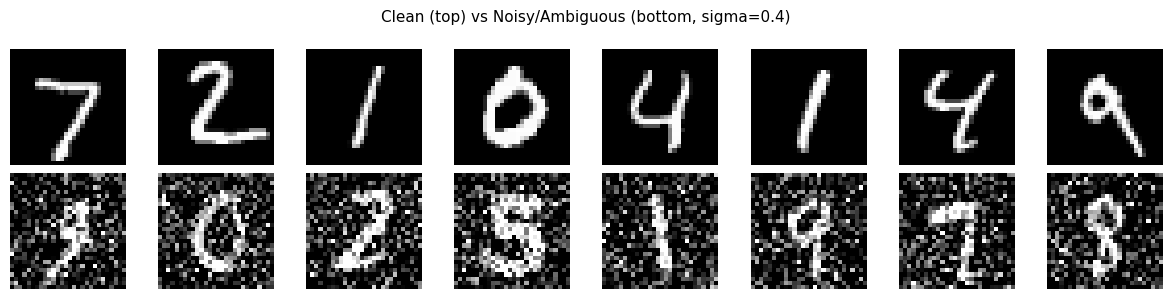

In [92]:
# Create a mixed dataset: half clean, half noisy (ambiguous)
n_half = N_TEST // 2
Xclean = Xte_i[:n_half]
yclean = yte[:n_half]

g_noise = torch.Generator().manual_seed(123)
noise_sigma = 0.4
Xnoisy = (Xte_i[n_half:2*n_half] + noise_sigma * torch.randn(
    n_half, 1, 28, 28, generator=g_noise)).clamp(0, 1)
ynoisy = yte[n_half:2*n_half]

Xmixed = torch.cat([Xclean, Xnoisy], dim=0)
ymixed = torch.cat([yclean, ynoisy], dim=0)
ambig_labels = torch.cat([torch.zeros(n_half), torch.ones(n_half)])  # 0=clean, 1=noisy

# Visualise
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
fig.suptitle(f"Clean (top) vs Noisy/Ambiguous (bottom, sigma={noise_sigma})", fontsize=11)
for i in range(8):
    axes[0, i].imshow(Xclean[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(Xnoisy[i, 0], cmap="gray"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [93]:
print("Computing uncertainties on mixed (clean + noisy) test set...")
u_mix = {}
u_mix["SNN"]              = snn_uncertainty(snn_model, Xmixed, ARCH, Np, Nm, DEVICE)
u_mix["MC Dropout"]       = mcd_uncertainty(mcd_model, Xmixed, ARCH, T_MCD, DEVICE)
u_mix["EDL"]              = edl_uncertainty(edl_model, Xmixed, ARCH, DEVICE)
u_mix["Deep Ensembles"]   = de_uncertainty(ensemble, Xmixed, ARCH, DEVICE)
u_mix["ICE (Hou et al.)"] = ice_uncertainty(ice_model, Xmixed, ARCH, N_CLARIFY, DEVICE)


def ambiguity_detection(u_dict, ambig_labels):
    alea = metrics._np(u_dict["aleatoric"])
    labels = metrics._np(ambig_labels).astype(int)
    auroc = metrics._roc_auc(alea, labels)
    f1 = best_f1_score(alea, labels)
    avg_clean = alea[labels == 0].mean()
    avg_noisy = alea[labels == 1].mean()
    return {"AUROC": auroc, "F1": f1 * 100,
            "Avg AU(clean)": avg_clean, "Avg AU(noisy)": avg_noisy}


rows2 = []
for name, u in u_mix.items():
    r = ambiguity_detection(u, ambig_labels)
    r["Method"] = name
    rows2.append(r)

df_ambig = pd.DataFrame(rows2)[["Method", "AUROC", "F1", "Avg AU(clean)", "Avg AU(noisy)"]]
print("\n=== Experiment 2: Ambiguity Detection (Paper Table 2 analogue) ===")
print(f"(Aleatoric uncertainty detects noisy/ambiguous inputs, sigma={noise_sigma})\n")
display(df_ambig.round(4))

Computing uncertainties on mixed (clean + noisy) test set...



=== Experiment 2: Ambiguity Detection (Paper Table 2 analogue) ===
(Aleatoric uncertainty detects noisy/ambiguous inputs, sigma=0.4)



/tmp/ipykernel_1272/1198529159.py:13: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)


,Method,AUROC,F1,Avg AU(clean),Avg AU(noisy)
0,SNN,0.9718,95.5969,0.0140,0.2041
1,MC Dropout,0.9448,91.9736,0.0359,0.2557
2,EDL,0.8453,89.5143,0.3430,0.3813
3,Deep Ensembles,0.9594,93.2498,0.0206,0.2212
4,ICE (Hou et al.),0.0175,66.6667,0.7042,0.1346


## 7. Experiment 3: Monotonicity Check (Paper Section 4.4, Figure 4a)

The paper verifies that aleatoric uncertainty **drops** after the input is clarified.
Our analogue: start with noisy (ambiguous) images, then "clarify" them by
denoising (removing the noise). The aleatoric uncertainty should be significantly
lower on the clarified (clean) version.


=== Experiment 3: Monotonicity Check (Paper Figure 4a analogue) ===
(Aleatoric uncertainty should drop after clarification)



,Method,Aleatoric (ambiguous),Aleatoric (clarified),Drop ratio
0,SNN,0.2073,0.0129,0.9377
1,MC Dropout,0.2547,0.0330,0.8705
2,Deep Ensembles,0.2234,0.0162,0.9276
3,ICE (Hou et al.),0.1391,0.6927,-3.9801


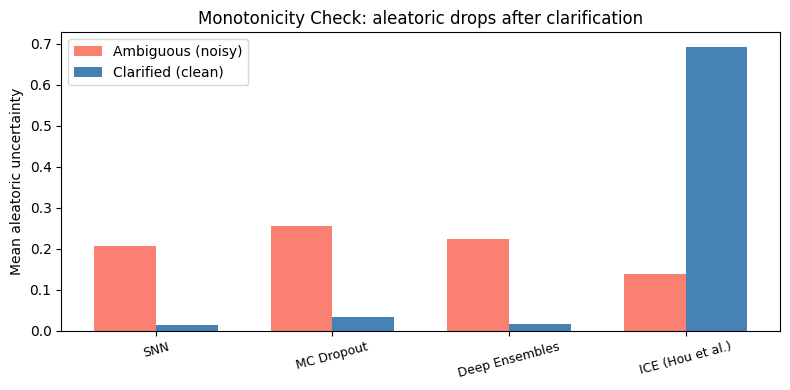

In [94]:
n_mono = min(500, n_half)
X_original   = Xte_i[:n_mono]          # clean original
X_ambiguous  = (X_original + noise_sigma * torch.randn_like(X_original)).clamp(0, 1)
X_clarified  = X_original              # "clarified" = denoised back to original

methods_mono = {
    "SNN":              lambda Xi: snn_uncertainty(snn_model, Xi, ARCH, Np, Nm, DEVICE),
    "MC Dropout":       lambda Xi: mcd_uncertainty(mcd_model, Xi, ARCH, T_MCD, DEVICE),
    "Deep Ensembles":   lambda Xi: de_uncertainty(ensemble, Xi, ARCH, DEVICE),
    "ICE (Hou et al.)": lambda Xi: ice_uncertainty(ice_model, Xi, ARCH, N_CLARIFY, DEVICE),
}

mono_rows = []
for name, fn in methods_mono.items():
    u_ambig    = fn(X_ambiguous)
    u_clarif   = fn(X_clarified)
    alea_ambig = metrics._np(u_ambig["aleatoric"]).mean()
    alea_clari = metrics._np(u_clarif["aleatoric"]).mean()
    mono_rows.append({
        "Method": name,
        "Aleatoric (ambiguous)": alea_ambig,
        "Aleatoric (clarified)": alea_clari,
        "Drop ratio": (alea_ambig - alea_clari) / max(alea_ambig, 1e-10),
    })

df_mono = pd.DataFrame(mono_rows)
print("\n=== Experiment 3: Monotonicity Check (Paper Figure 4a analogue) ===")
print("(Aleatoric uncertainty should drop after clarification)\n")
display(df_mono.round(4))

# Bar plot
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_mono))
w = 0.35
ax.bar(x - w/2, df_mono["Aleatoric (ambiguous)"], w, label="Ambiguous (noisy)", color="salmon")
ax.bar(x + w/2, df_mono["Aleatoric (clarified)"], w, label="Clarified (clean)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(df_mono["Method"], fontsize=9, rotation=15)
ax.set_ylabel("Mean aleatoric uncertainty")
ax.set_title("Monotonicity Check: aleatoric drops after clarification")
ax.legend()
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/monotonicity_check.png", dpi=140)
plt.show()

## 8. Experiment 4: OOD Detection

Not in the paper's main experiments, but a standard uncertainty evaluation.
Use **epistemic** and **total** uncertainty to detect FashionMNIST (OOD) vs MNIST (ID).

In [95]:
print("Computing uncertainties on OOD (FashionMNIST)...")
u_ood = {}
u_ood["SNN"]              = snn_uncertainty(snn_model, Xood_i, ARCH, Np, Nm, DEVICE)
u_ood["MC Dropout"]       = mcd_uncertainty(mcd_model, Xood_i, ARCH, T_MCD, DEVICE)
u_ood["EDL"]              = edl_uncertainty(edl_model, Xood_i, ARCH, DEVICE)
u_ood["Deep Ensembles"]   = de_uncertainty(ensemble, Xood_i, ARCH, DEVICE)
u_ood["ICE (Hou et al.)"] = ice_uncertainty(ice_model, Xood_i, ARCH, N_CLARIFY, DEVICE)


def ood_detection(u_id, u_ood_dict, score_key):
    s_id  = metrics._np(u_id[score_key])
    s_ood = metrics._np(u_ood_dict[score_key])
    om = metrics.ood_metrics(s_id, s_ood)
    return om


rows_ood = []
for name in all_methods:
    u_id_dict = all_methods[name]
    u_ood_dict = u_ood[name]
    om_total = ood_detection(u_id_dict, u_ood_dict, "total")
    om_epi   = ood_detection(u_id_dict, u_ood_dict, "epistemic")
    om_alea  = ood_detection(u_id_dict, u_ood_dict, "aleatoric")
    rows_ood.append({
        "Method": name,
        "AUROC (total)": om_total["auroc"],
        "AUROC (epistemic)": om_epi["auroc"],
        "AUROC (aleatoric)": om_alea["auroc"],
        "FPR@95 (total)": om_total["fpr95"],
    })

df_ood = pd.DataFrame(rows_ood)
print("\n=== Experiment 4: OOD Detection (MNIST ID vs FashionMNIST OOD) ===")
print("(Higher AUROC = better OOD detection)\n")
display(df_ood.round(4))

Computing uncertainties on OOD (FashionMNIST)...



=== Experiment 4: OOD Detection (MNIST ID vs FashionMNIST OOD) ===
(Higher AUROC = better OOD detection)



,Method,AUROC (total),AUROC (epistemic),AUROC (aleatoric),FPR@95 (total)
0,SNN,0.9579,0.9672,0.9578,0.1515
1,MC Dropout,0.9626,0.9667,0.9611,0.1240
2,EDL,0.9576,0.9576,0.9563,0.1195
3,Deep Ensembles,0.9953,0.9954,0.9902,0.0235
4,ICE (Hou et al.),0.1673,0.2156,0.1914,0.9955


## 9. Rotation Sweep: Full Decomposition Comparison

Progressively rotate test digits 0 -> 180 deg and track how each method's
epistemic and aleatoric components evolve. This is the image analogue of
increasing input ambiguity (rotation makes digits harder to recognise).

In [96]:
n_sweep = min(500, N_TEST)
Xsweep_i = Xte_i[:n_sweep]
ysweep   = yte[:n_sweep]
angles   = list(range(0, 181, 15))

sweep_data = {name: {"angle": [], "acc": [], "total": [], "epi": [], "alea": [], "u_star": []}
              for name in ["SNN", "MC Dropout", "Deep Ensembles", "ICE (Hou et al.)"]}

print(f"Rotation sweep ({n_sweep} digits, {len(angles)} angles)...")
for ang in angles:
    Xr = run_mnist.rotate_batch(Xsweep_i, ang)
    yr = ysweep

    for name, fn in [
        ("SNN",              lambda Xi: snn_uncertainty(snn_model, Xi, ARCH, Np, Nm, DEVICE)),
        ("MC Dropout",       lambda Xi: mcd_uncertainty(mcd_model, Xi, ARCH, T_MCD, DEVICE)),
        ("Deep Ensembles",   lambda Xi: de_uncertainty(ensemble, Xi, ARCH, DEVICE)),
        ("ICE (Hou et al.)", lambda Xi: ice_uncertainty(ice_model, Xi, ARCH, N_CLARIFY, DEVICE)),
    ]:
        u = fn(Xr)
        acc = metrics.accuracy(u["probs"], yr)
        sweep_data[name]["angle"].append(ang)
        sweep_data[name]["acc"].append(acc)
        sweep_data[name]["total"].append(metrics._np(u["total"]).mean())
        sweep_data[name]["epi"].append(metrics._np(u["epistemic"]).mean())
        sweep_data[name]["alea"].append(metrics._np(u["aleatoric"]).mean())
        sweep_data[name]["u_star"].append(metrics._np(u["u_star"]).mean())

    print(f"  {ang:3d} deg done")

print("Sweep complete.")

Rotation sweep (500 digits, 13 angles)...


    0 deg done


   15 deg done


   30 deg done


   45 deg done


...

  120 deg done


  135 deg done


  150 deg done


  165 deg done


  180 deg done
Sweep complete.


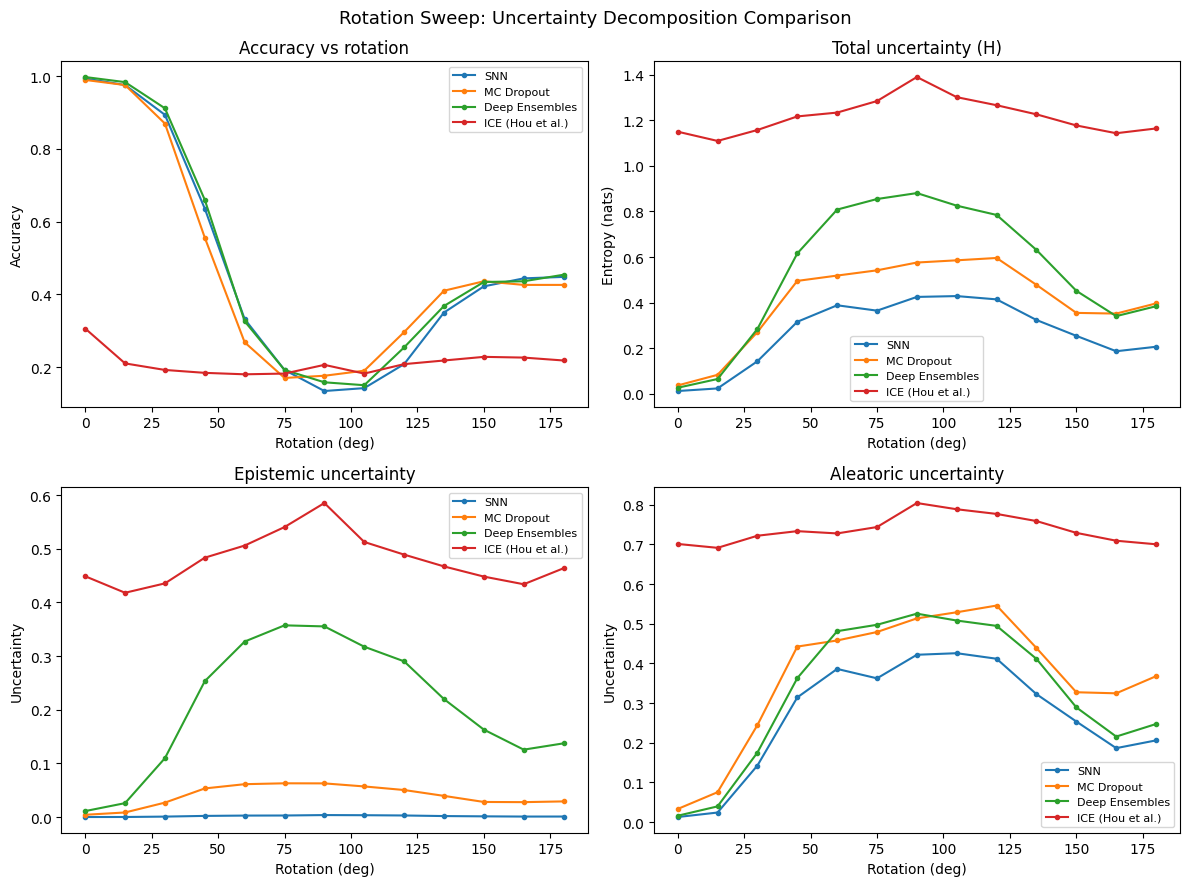

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
colors = {"SNN": "tab:blue", "MC Dropout": "tab:orange",
          "Deep Ensembles": "tab:green", "ICE (Hou et al.)": "tab:red"}

# Accuracy
ax = axes[0, 0]
for name, sd in sweep_data.items():
    ax.plot(sd["angle"], sd["acc"], "-o", ms=3, label=name, color=colors[name])
ax.set_title("Accuracy vs rotation"); ax.set_xlabel("Rotation (deg)")
ax.set_ylabel("Accuracy"); ax.legend(fontsize=8)

# Total uncertainty
ax = axes[0, 1]
for name, sd in sweep_data.items():
    ax.plot(sd["angle"], sd["total"], "-o", ms=3, label=name, color=colors[name])
ax.set_title("Total uncertainty (H)"); ax.set_xlabel("Rotation (deg)")
ax.set_ylabel("Entropy (nats)"); ax.legend(fontsize=8)

# Epistemic
ax = axes[1, 0]
for name, sd in sweep_data.items():
    ax.plot(sd["angle"], sd["epi"], "-o", ms=3, label=name, color=colors[name])
ax.set_title("Epistemic uncertainty"); ax.set_xlabel("Rotation (deg)")
ax.set_ylabel("Uncertainty"); ax.legend(fontsize=8)

# Aleatoric
ax = axes[1, 1]
for name, sd in sweep_data.items():
    ax.plot(sd["angle"], sd["alea"], "-o", ms=3, label=name, color=colors[name])
ax.set_title("Aleatoric uncertainty"); ax.set_xlabel("Rotation (deg)")
ax.set_ylabel("Uncertainty"); ax.legend(fontsize=8)

fig.suptitle("Rotation Sweep: Uncertainty Decomposition Comparison", fontsize=13)
fig.tight_layout()
plt.savefig("results/comparison_rotation_sweep.png", dpi=140)
plt.show()

## 10. Summary

### Combined comparison table

In [98]:
summary_rows = []
for name in all_methods:
    md = df_mistake[df_mistake["Method"] == name].iloc[0]
    ad = df_ambig[df_ambig["Method"] == name].iloc[0]
    od = df_ood[df_ood["Method"] == name].iloc[0]
    summary_rows.append({
        "Method": name,
        "Acc": md["Acc"],
        "Mistake Det. AUROC": md["AUROC"],
        "Mistake Det. F1": md["F1"],
        "Ambig Det. AUROC": ad["AUROC"],
        "Ambig Det. F1": ad["F1"],
        "OOD AUROC (total)": od["AUROC (total)"],
        "OOD AUROC (epi)": od["AUROC (epistemic)"],
    })

df_summary = pd.DataFrame(summary_rows)
print("=" * 80)
print("FULL COMPARISON: SNN vs Input Clarification Ensembling (Hou et al. 2024)")
print("=" * 80)
display(df_summary.round(4))

FULL COMPARISON: SNN vs Input Clarification Ensembling (Hou et al. 2024)


,Method,Acc,Mistake Det. AUROC,Mistake Det. F1,Ambig Det. AUROC,Ambig Det. F1,OOD AUROC (total),OOD AUROC (epi)
0,SNN,0.9910,0.9906,66.6667,0.9718,95.5969,0.9579,0.9672
1,MC Dropout,0.9860,0.9782,53.3333,0.9448,91.9736,0.9626,0.9667
2,EDL,0.9770,0.9918,86.0465,0.8453,89.5143,0.9576,0.9576
3,Deep Ensembles,0.9935,0.9886,46.5116,0.9594,93.2498,0.9953,0.9954
4,ICE (Hou et al.),0.3140,0.7793,86.0450,0.0175,66.6667,0.1673,0.2156


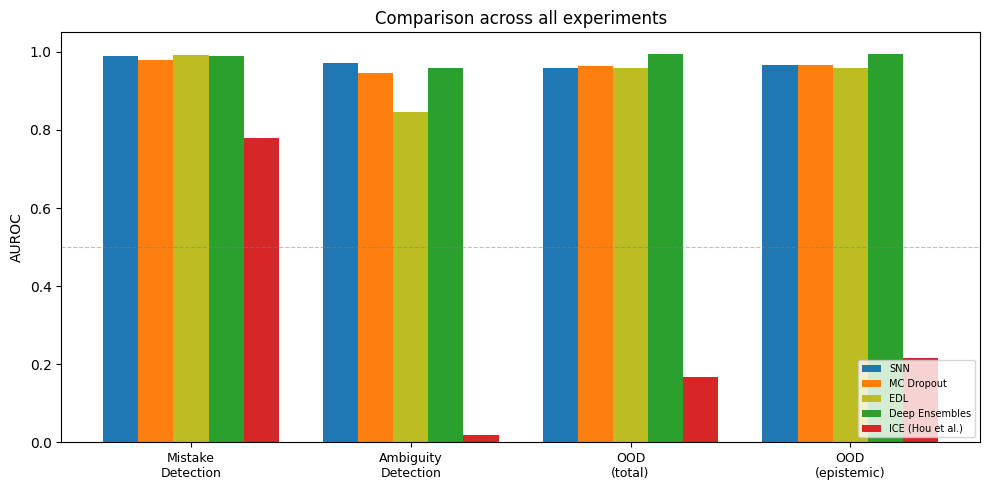

In [99]:
# Radar-style bar chart
metric_cols = ["Mistake Det. AUROC", "Ambig Det. AUROC",
               "OOD AUROC (total)", "OOD AUROC (epi)"]
short_labels = ["Mistake\nDetection", "Ambiguity\nDetection",
                "OOD\n(total)", "OOD\n(epistemic)"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_cols))
n_methods = len(df_summary)
w = 0.8 / n_methods
method_colors = ["tab:blue", "tab:orange", "tab:olive", "tab:green", "tab:red"]

for i, (_, row) in enumerate(df_summary.iterrows()):
    vals = [row[c] for c in metric_cols]
    ax.bar(x + i * w - 0.4 + w/2, vals, w, label=row["Method"],
           color=method_colors[i % len(method_colors)])

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel("AUROC")
ax.set_title("Comparison across all experiments")
ax.legend(fontsize=7, loc="lower right")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig("results/comparison_summary.png", dpi=140)
plt.show()

### Key takeaways

**Symmetry of the decomposition:**
SNN and ICE use the same mathematical decomposition (H = MI + eH) but assign
the terms to opposite uncertainty types. This is because:
- **SNN/BNN** varies the *model* -> MI captures model disagreement -> **epistemic**
- **ICE** varies the *input* -> MI captures input sensitivity -> **aleatoric**

**When each method excels:**
- SNN's model-side decomposition naturally captures epistemic uncertainty (OOD, data scarcity)
- ICE's input-side decomposition naturally captures aleatoric uncertainty (input ambiguity)
- Deep Ensembles and MC Dropout fall between the two

**Complementarity:**
The two approaches are complementary: SNN decomposes model-side uncertainty,
ICE decomposes input-side uncertainty. A combined system could leverage both.

In [100]:
# Save all results for reproducibility
results = {
    "mistake_detection": df_mistake.to_dict(orient="records"),
    "ambiguity_detection": df_ambig.to_dict(orient="records"),
    "monotonicity_check": df_mono.to_dict(orient="records"),
    "ood_detection": df_ood.to_dict(orient="records"),
    "summary": df_summary.to_dict(orient="records"),
    "rotation_sweep": {name: sd for name, sd in sweep_data.items()},
    "config": {
        "arch": ARCH, "epochs": EPOCHS, "d_hidden": D_HIDDEN,
        "Np": Np, "Nm": Nm, "T_mcd": T_MCD,
        "n_ensemble": N_ENSEMBLE, "n_clarify": N_CLARIFY,
        "n_test": N_TEST, "noise_sigma": noise_sigma,
    },
}
os.makedirs("results", exist_ok=True)
with open("results/comparison_snn_vs_ice.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print("Results saved to results/comparison_snn_vs_ice.json")

Results saved to results/comparison_snn_vs_ice.json
